### Step 0 :- Import Libraries

In [1]:
# Import Pandas
import pandas as pd

# Import NumPy
import numpy as np

# Import Matplotlib
import matplotlib.pyplot as plt

# Import train-test split
from sklearn.model_selection import train_test_split

# Import ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# Import model evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error)

### Step 1 :- Load Dataset

In [2]:
# Load dataset
quantity_data = pd.read_excel('Raw Data_Predictive Analysis.xlsx')

#### Display Dataset Information

In [3]:
# Display dataset shape
print(f'Dataset Shape: {quantity_data.shape}')

# Display column names
print(f'\nColumns:\n{quantity_data.columns}')

# Display first 5 rows
quantity_data.head()

Dataset Shape: (40563, 9)

Columns:
Index(['OrderDate', 'ParentProductIdNew', 'ParentProductNew',
       'ProductCategoryNew', 'ArtistNameNew', 'total_qty_sales',
       'Selling Price', 'productListViews', 'productListClicks'],
      dtype='str')


,OrderDate,ParentProductIdNew,ParentProductNew,ProductCategoryNew,ArtistNameNew,total_qty_sales,Selling Price,productListViews,productListClicks
0,2019-01-01,11,Product 11,Category 1,TSSOS,3,399.0,NaN,NaN
1,2019-01-01,114,Product 114,Category 8,TSSA,10,549.0,NaN,NaN
2,2019-01-01,98,Product 98,Category 8,TSSHT,8,499.0,NaN,NaN
3,2019-01-01,97,Product 97,Category 8,TSSF,6,549.0,NaN,NaN
4,2019-01-01,8,Product 8,Category 1,TSSML,6,399.0,NaN,NaN


#### Check Dataset Information

In [4]:
# Display dataset information
quantity_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40563 entries, 0 to 40562
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   OrderDate           40563 non-null  datetime64[us]
 1   ParentProductIdNew  40563 non-null  int64         
 2   ParentProductNew    40563 non-null  str           
 3   ProductCategoryNew  40563 non-null  str           
 4   ArtistNameNew       40563 non-null  str           
 5   total_qty_sales     40563 non-null  int64         
 6   Selling Price       40563 non-null  float64       
 7   productListViews    25591 non-null  float64       
 8   productListClicks   25591 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 3.8 MB


### Step 2 :- Exploratory Data Analysis

#### Display First 5 Rows

In [5]:
# Display first 5 rows
quantity_data.head()

,OrderDate,ParentProductIdNew,ParentProductNew,ProductCategoryNew,ArtistNameNew,total_qty_sales,Selling Price,productListViews,productListClicks
0,2019-01-01,11,Product 11,Category 1,TSSOS,3,399.0,NaN,NaN
1,2019-01-01,114,Product 114,Category 8,TSSA,10,549.0,NaN,NaN
2,2019-01-01,98,Product 98,Category 8,TSSHT,8,499.0,NaN,NaN
3,2019-01-01,97,Product 97,Category 8,TSSF,6,549.0,NaN,NaN
4,2019-01-01,8,Product 8,Category 1,TSSML,6,399.0,NaN,NaN


#### Display Last 5 Rows

In [6]:
# Display last 5 rows
quantity_data.tail()

,OrderDate,ParentProductIdNew,ParentProductNew,ProductCategoryNew,ArtistNameNew,total_qty_sales,Selling Price,productListViews,productListClicks
40558,2020-12-31,18,Product 18,Category 2,TSSDP,19,570.052632,12004.0,104.0
40559,2020-12-31,76,Product 76,Category 6,TSSML,16,861.500000,2367.0,76.0
40560,2020-12-31,21,Product 21,Category 2,TSSML,5,619.000000,3697.0,60.0
40561,2020-12-31,52,Product 52,Category 4,TSSCC,18,1299.000000,34690.0,553.0
40562,2020-12-31,67,Product 67,Category 5,TSSML,10,1732.222222,23826.0,393.0


#### Check Dataset Shape

In [7]:
# Display dataset shape
print(f'Rows: {quantity_data.shape[0]}')

print(f'Columns: {quantity_data.shape[1]}')

Rows: 40563
Columns: 9


#### Check Data Types

In [8]:
# Display data types
quantity_data.dtypes

OrderDate             datetime64[us]
ParentProductIdNew             int64
ParentProductNew                 str
ProductCategoryNew               str
ArtistNameNew                    str
total_qty_sales                int64
Selling Price                float64
productListViews             float64
productListClicks            float64
dtype: object

#### Check Missing Values

In [9]:
# Display missing values
quantity_data.isnull().sum()

OrderDate                 0
ParentProductIdNew        0
ParentProductNew          0
ProductCategoryNew        0
ArtistNameNew             0
total_qty_sales           0
Selling Price             0
productListViews      14972
productListClicks     14972
dtype: int64

#### Check Duplicate Records

In [10]:
# Display duplicate records
print(f'Duplicate Records: {quantity_data.duplicated().sum()}')

Duplicate Records: 0


#### Display Summary Statistics

In [11]:
# Display summary statistics
quantity_data.describe()

,OrderDate,ParentProductIdNew,total_qty_sales,Selling Price,productListViews,productListClicks
count,40563,40563.000000,40563.000000,40563.000000,25591.000000,25591.000000
mean,2020-03-15 13:02:53.330375,62.087863,14.335453,607.727903,8860.939940,215.843265
min,2019-01-01 00:00:00,1.000000,1.000000,99.000000,1.000000,0.000000
25%,2019-10-28 00:00:00,31.000000,3.000000,449.000000,2451.000000,38.000000
50%,2020-04-05 00:00:00,65.000000,8.000000,499.000000,5026.000000,84.000000
75%,2020-09-02 00:00:00,97.000000,16.000000,644.161290,11441.000000,204.000000
max,2020-12-31 00:00:00,114.000000,4144.000000,2994.000000,219578.000000,19657.000000
std,NaN,36.550756,34.820774,282.939037,10627.960951,499.114425


#### Display Feature Names

In [12]:
# Display column names
quantity_data.columns

Index(['OrderDate', 'ParentProductIdNew', 'ParentProductNew',
       'ProductCategoryNew', 'ArtistNameNew', 'total_qty_sales',
       'Selling Price', 'productListViews', 'productListClicks'],
      dtype='str')

#### Check Quantity Distribution

> Replace `Quantity` with your actual quantity column name if it is different.

In [13]:
# Display quantity statistics
quantity_data['total_qty_sales'].describe()

count    40563.000000
mean        14.335453
std         34.820774
min          1.000000
25%          3.000000
50%          8.000000
75%         16.000000
max       4144.000000
Name: total_qty_sales, dtype: float64

#### Quantity Trend

> Replace `OrderDate` with your actual date column name if it is different.

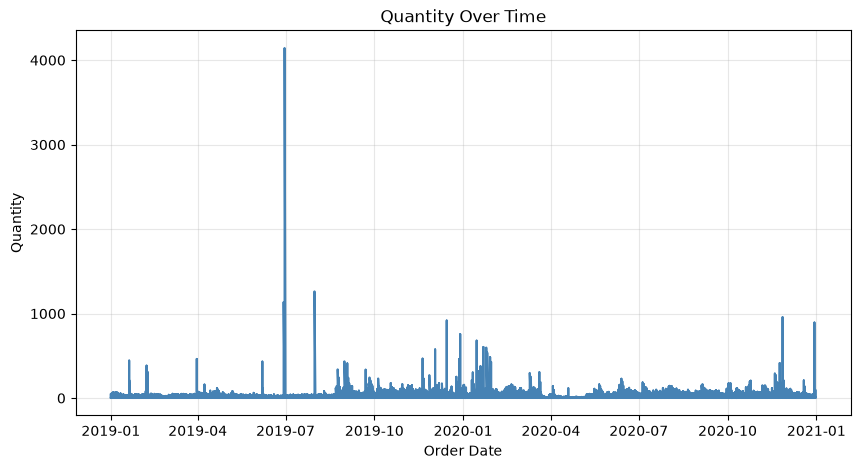

In [14]:
# Create figure
plt.figure(figsize = (10, 5))

# Plot quantity trend
plt.plot(

    quantity_data['OrderDate'],

    quantity_data['total_qty_sales'],

    color = 'steelblue')

# Chart title
plt.title('Quantity Over Time')

# X-axis label
plt.xlabel('Order Date')

# Y-axis label
plt.ylabel('Quantity')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

### Step 3 :- Data Preprocessing

#### Fill Missing Values

In [15]:
# Fill missing values
quantity_data['productListViews'] = quantity_data['productListViews'].fillna(0)

quantity_data['productListClicks'] = quantity_data['productListClicks'].fillna(0)

#### Remove Duplicate Records

In [16]:
# Remove duplicate records
quantity_data = quantity_data.drop_duplicates()

# Display duplicate records
print(f'Duplicate Records: {quantity_data.duplicated().sum()}')

Duplicate Records: 0


#### Convert Date Column

> Replace `OrderDate` with your actual date column name if it is different.

In [17]:
# Convert date column
quantity_data['OrderDate'] = pd.to_datetime(

    quantity_data['OrderDate'],

    errors = 'coerce')

# Display data type
print(quantity_data['OrderDate'].dtype)

datetime64[us]


#### Sort Dataset by Date

In [18]:
# Sort dataset by date
quantity_data = quantity_data.sort_values(

    'OrderDate')

#### Create Daily Time Series

In [19]:
# Create daily time series
quantity_series = quantity_data.groupby(

    'OrderDate'

)['total_qty_sales'].sum()

quantity_series.head()

OrderDate
2019-01-01    293
2019-01-02    351
2019-01-03    319
2019-01-04    341
2019-01-05    308
Name: total_qty_sales, dtype: int64

#### Set Daily Frequency

In [20]:
# Set daily frequency
quantity_series = quantity_series.asfreq(

    'D',

    fill_value = 0)

quantity_series.head()

OrderDate
2019-01-01    293
2019-01-02    351
2019-01-03    319
2019-01-04    341
2019-01-05    308
Freq: D, Name: total_qty_sales, dtype: int64

#### Display Dataset Information

In [21]:
# Display dataset information
print(f'Total Days: {len(quantity_series)}')

print(f'Start Date: {quantity_series.index.min()}')

print(f'End Date: {quantity_series.index.max()}')

Total Days: 731
Start Date: 2019-01-01 00:00:00
End Date: 2020-12-31 00:00:00


### Step 4 :- Time Series Analysis

#### Display Time Series Data

In [22]:
# Display first 5 records
quantity_series.head()

OrderDate
2019-01-01    293
2019-01-02    351
2019-01-03    319
2019-01-04    341
2019-01-05    308
Freq: D, Name: total_qty_sales, dtype: int64

#### Plot Daily Sales Trend

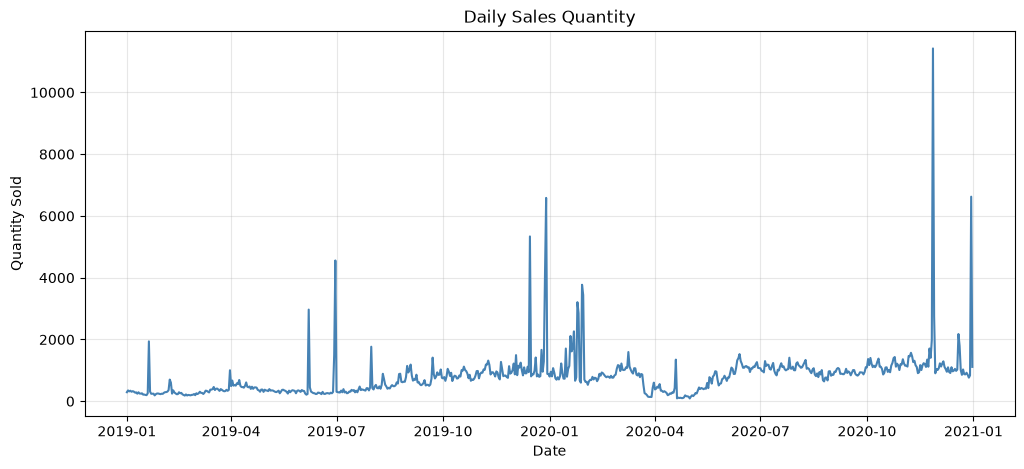

In [23]:
# Create figure
plt.figure(figsize = (12, 5))

# Plot daily quantity
plt.plot(

    quantity_series,

    color = 'steelblue')

# Chart title
plt.title('Daily Sales Quantity')

# X-axis label
plt.xlabel('Date')

# Y-axis label
plt.ylabel('Quantity Sold')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Monthly Sales Trend

In [24]:
# Calculate monthly sales
monthly_quantity = quantity_series.resample(

    'ME'

).sum()

monthly_quantity.head()

OrderDate
2019-01-31     9820
2019-02-28     7766
2019-03-31    10922
2019-04-30    13968
2019-05-31    10188
Freq: ME, Name: total_qty_sales, dtype: int64

#### Plot Monthly Sales Trend

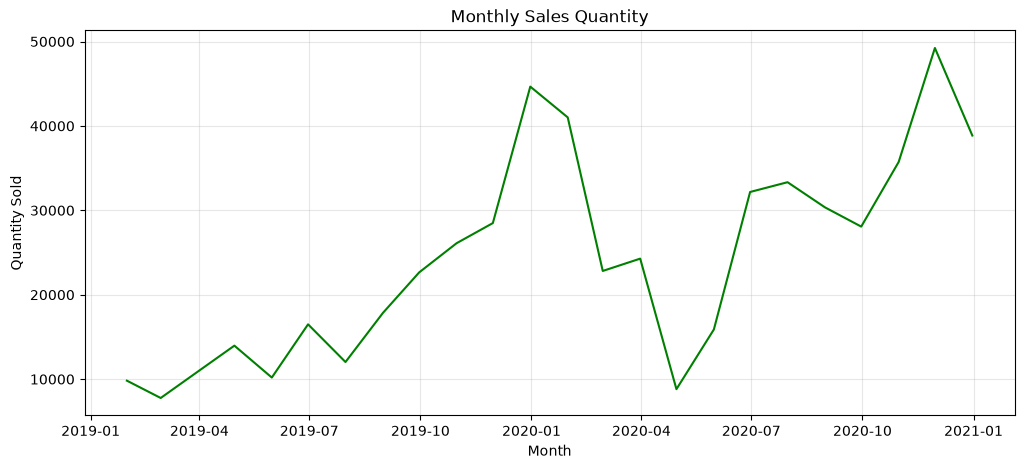

In [25]:
# Create figure
plt.figure(figsize = (12, 5))

# Plot monthly sales
plt.plot(

    monthly_quantity,

    color = 'green')

# Chart title
plt.title('Monthly Sales Quantity')

# X-axis label
plt.xlabel('Month')

# Y-axis label
plt.ylabel('Quantity Sold')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Calculate 7-Day Moving Average

In [26]:
# Calculate moving average
moving_average = quantity_series.rolling(

    window = 7

).mean()

moving_average.head()

OrderDate
2019-01-01   NaN
2019-01-02   NaN
2019-01-03   NaN
2019-01-04   NaN
2019-01-05   NaN
Freq: D, Name: total_qty_sales, dtype: float64

#### Plot Daily Sales vs Moving Average

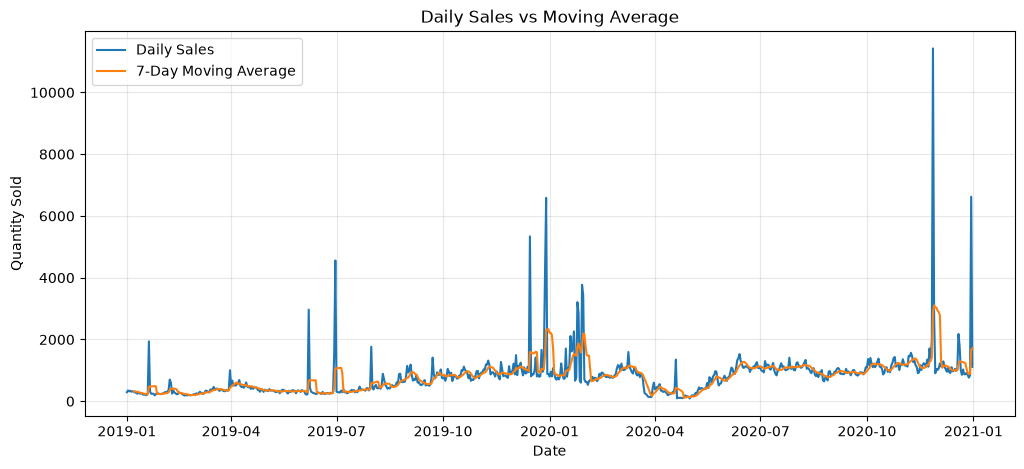

In [27]:
# Create figure
plt.figure(figsize = (12, 5))

# Plot daily sales
plt.plot(

    quantity_series,

    label = 'Daily Sales'

)

# Plot moving average
plt.plot(

    moving_average,

    label = '7-Day Moving Average')

# Chart title
plt.title('Daily Sales vs Moving Average')

# X-axis label
plt.xlabel('Date')

# Y-axis label
plt.ylabel('Quantity Sold')

# Show legend
plt.legend()

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

### Step 5 :- Model Training

#### Split Training and Testing Data

In [28]:
# Split data
train_size = int(

    len(quantity_series) * 0.8)

train_data = quantity_series.iloc[:train_size]

test_data = quantity_series.iloc[train_size:]

# Display dataset size
print(f'Training Data: {len(train_data)}')

print(f'Testing Data: {len(test_data)}')

Training Data: 584
Testing Data: 147


#### Create ARIMA Model

In [29]:
# Create ARIMA model
arima_model = ARIMA(

    train_data,

    order = (5, 1, 0))

#### Train ARIMA Model

In [30]:
# Train ARIMA model
trained_model = arima_model.fit()

#### Display Model Summary

In [31]:
# Display model summary
print(trained_model.summary())

                               SARIMAX Results                                
Dep. Variable:        total_qty_sales   No. Observations:                  584
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4424.823
Date:                Thu, 02 Jul 2026   AIC                           8861.647
Time:                        22:20:38   BIC                           8887.856
Sample:                    01-01-2019   HQIC                          8871.862
                         - 08-06-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5412      0.014    -40.058      0.000      -0.568      -0.515
ar.L2         -0.5612      0.023    -24.278      0.000      -0.607      -0.516
ar.L3         -0.3881      0.026    -15.011      0.0

#### Predict Test Data

In [32]:
# Predict test data
predicted_quantity = trained_model.forecast(

    steps = len(test_data))

predicted_quantity.index = test_data.index

predicted_quantity.head()

OrderDate
2020-08-07    1143.926434
2020-08-08    1146.045534
2020-08-09    1125.990911
2020-08-10    1121.332260
2020-08-11    1125.057803
Freq: D, Name: predicted_mean, dtype: float64

#### Compare Actual vs Predicted

In [33]:
# Compare actual and predicted values
prediction_results = pd.DataFrame({

    'Actual Quantity': test_data.values,

    'Predicted Quantity': predicted_quantity.values},

index = test_data.index)

prediction_results.head(10)

,Actual Quantity,Predicted Quantity
OrderDate,,
2020-08-07,1177,1143.926434
2020-08-08,1254,1146.045534
2020-08-09,1338,1125.990911
2020-08-10,1052,1121.332260
2020-08-11,1074,1125.057803
2020-08-12,1044,1128.459791
2020-08-13,962,1129.565650
2020-08-14,910,1128.570661
2020-08-15,1023,1127.026674


#### Model Evaluation Metrics (MAE, MSE, RMSE)

In [34]:
# Calculate MAE
mae = mean_absolute_error(

    test_data,

    predicted_quantity)

# Calculate MSE
mse = mean_squared_error(

    test_data,

    predicted_quantity)

# Calculate RMSE
rmse = np.sqrt(

    mse)

# Display evaluation metrics
print(f'MAE: {mae:.2f}')

print(f'MSE: {mse:.2f}')

print(f'RMSE: {rmse:.2f}')

MAE: 293.27
MSE: 998799.84
RMSE: 999.40


### Step 6 :- Forecasting

#### Forecast Future Quantity

In [35]:
# Forecast next 30 periods
future_forecast = trained_model.forecast(

    steps = 30)

future_forecast.head()

2020-08-07    1143.926434
2020-08-08    1146.045534
2020-08-09    1125.990911
2020-08-10    1121.332260
2020-08-11    1125.057803
Freq: D, Name: predicted_mean, dtype: float64

#### Create Forecast Dates

In [36]:
# Create forecast dates
forecast_dates = pd.date_range(

    start = quantity_series.index[-1] + pd.Timedelta(days = 1),

    periods = 30,

    freq = 'D')

forecast_dates

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10', '2021-01-11', '2021-01-12',
               '2021-01-13', '2021-01-14', '2021-01-15', '2021-01-16',
               '2021-01-17', '2021-01-18', '2021-01-19', '2021-01-20',
               '2021-01-21', '2021-01-22', '2021-01-23', '2021-01-24',
               '2021-01-25', '2021-01-26', '2021-01-27', '2021-01-28',
               '2021-01-29', '2021-01-30'],
              dtype='datetime64[us]', freq='D')

#### Create Forecast DataFrame

In [37]:
# Create forecast dataframe
forecast_data = pd.DataFrame({

    'Date': forecast_dates,

    'Forecast Quantity': future_forecast.values})

forecast_data.head()

,Date,Forecast Quantity
0,2021-01-01,1143.926434
1,2021-01-02,1146.045534
2,2021-01-03,1125.990911
3,2021-01-04,1121.332260
4,2021-01-05,1125.057803


#### Display Forecast Values

In [38]:
# Display forecast values
forecast_data

,Date,Forecast Quantity
0,2021-01-01,1143.926434
1,2021-01-02,1146.045534
2,2021-01-03,1125.990911
3,2021-01-04,1121.332260
4,2021-01-05,1125.057803
5,2021-01-06,1128.459791
6,2021-01-07,1129.565650
7,2021-01-08,1128.570661
8,2021-01-09,1127.026674
9,2021-01-10,1127.004615


#### Display Forecast Summary

In [39]:
# Display forecast summary
forecast_data.describe()

,Date,Forecast Quantity
count,30,30.000000
mean,2021-01-15 12:00:00,1128.576487
min,2021-01-01 00:00:00,1121.332260
25%,2021-01-08 06:00:00,1127.675902
50%,2021-01-15 12:00:00,1127.700092
75%,2021-01-22 18:00:00,1127.728554
max,2021-01-30 00:00:00,1146.045534
std,NaN,4.672468


#### Display Total Forecast Quantity

In [40]:
# Display total forecast quantity
print(f'Total Forecast Quantity: {forecast_data["Forecast Quantity"].sum():.2f}')

Total Forecast Quantity: 33857.29


### Step 7 :- Visualization

#### Actual vs Predicted Sales

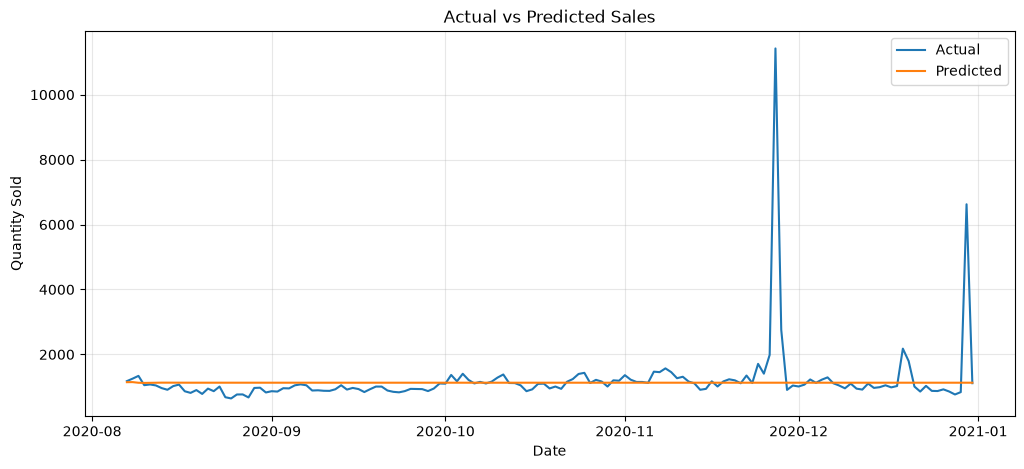

In [41]:
# Create figure
plt.figure(figsize = (12, 5))

# Plot actual sales
plt.plot(

    test_data.index,

    test_data,

    label = 'Actual'

)

# Plot predicted sales
plt.plot(

    predicted_quantity.index,

    predicted_quantity,

    label = 'Predicted')

# Chart title
plt.title('Actual vs Predicted Sales')

# X-axis label
plt.xlabel('Date')

# Y-axis label
plt.ylabel('Quantity Sold')

# Show legend
plt.legend()

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Historical vs Forecast Sales

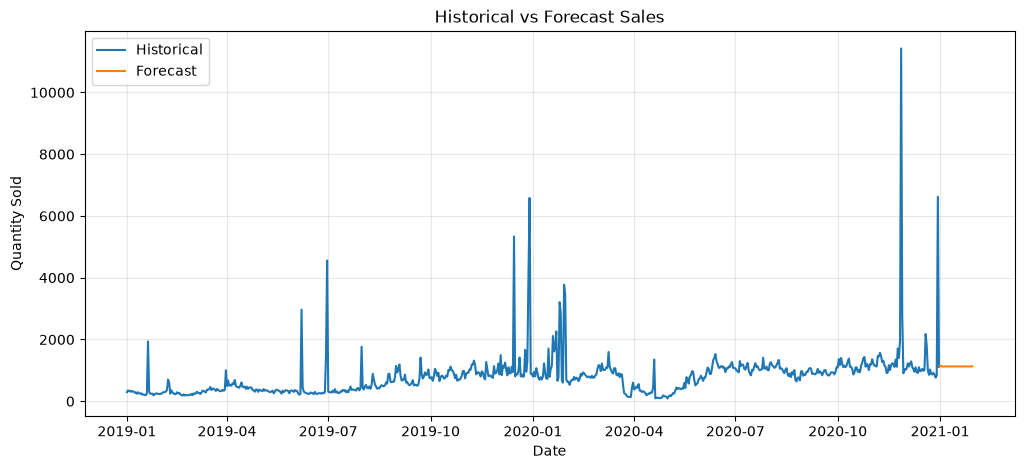

In [42]:
# Create figure
plt.figure(figsize = (12, 5))

# Plot historical sales
plt.plot(

    quantity_series,

    label = 'Historical'

)

# Plot forecast sales
plt.plot(

    forecast_data['Date'],

    forecast_data['Forecast Quantity'],

    label = 'Forecast')

# Chart title
plt.title('Historical vs Forecast Sales')

# X-axis label
plt.xlabel('Date')

# Y-axis label
plt.ylabel('Quantity Sold')

# Show legend
plt.legend()

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### 30-Day Forecast

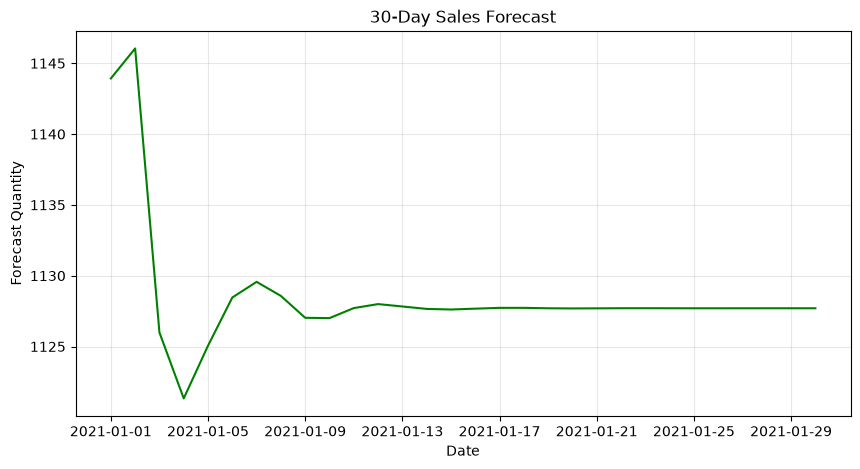

In [43]:
# Create figure
plt.figure(figsize = (10, 5))

# Plot forecast
plt.plot(

    forecast_data['Date'],

    forecast_data['Forecast Quantity'],

    color = 'green')

# Chart title
plt.title('30-Day Sales Forecast')

# X-axis label
plt.xlabel('Date')

# Y-axis label
plt.ylabel('Forecast Quantity')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Daily Sales vs 7-Day Moving Average

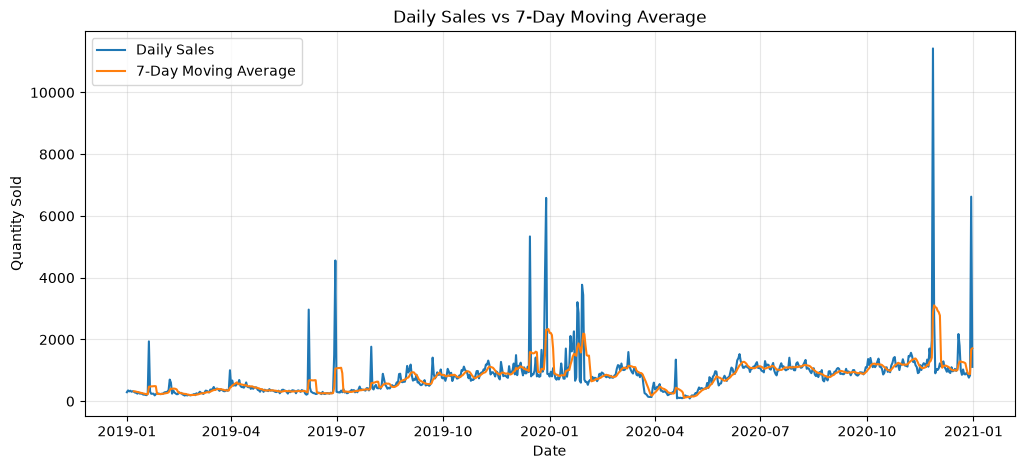

In [44]:
# Create figure
plt.figure(figsize = (12, 5))

# Plot daily sales
plt.plot(

    quantity_series,

    label = 'Daily Sales'

)

# Plot moving average
plt.plot(

    moving_average,

    label = '7-Day Moving Average')

# Chart title
plt.title('Daily Sales vs 7-Day Moving Average')

# X-axis label
plt.xlabel('Date')

# Y-axis label
plt.ylabel('Quantity Sold')

# Show legend
plt.legend()

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Forecast Summary

In [45]:
# Display forecast summary
forecast_data.describe()

,Date,Forecast Quantity
count,30,30.000000
mean,2021-01-15 12:00:00,1128.576487
min,2021-01-01 00:00:00,1121.332260
25%,2021-01-08 06:00:00,1127.675902
50%,2021-01-15 12:00:00,1127.700092
75%,2021-01-22 18:00:00,1127.728554
max,2021-01-30 00:00:00,1146.045534
std,NaN,4.672468


#### Step 8 :- Information

> Dataset: Predictive Sales Analysis

> Source File:
> - Raw Data_Predictive Analysis.xlsx

> Forecasting Algorithm:
> - ARIMA (AutoRegressive Integrated Moving Average)

> Input Features:
> - OrderDate
> - ParentProductIdNew
> - ParentProductNew
> - ProductCategoryNew
> - ArtistNameNew
> - Selling Price
> - productListViews
> - productListClicks

> Target Variable:
> - total_qty_sales

> Total Records:
> - 40,563

> Total Features:
> - 9

> Time Period:
> - 01-Jan-2019 to 31-Dec-2020

> Data Preprocessing:
> - Missing values filled
> - Duplicate records removed
> - Date column converted to datetime
> - Daily time series created
> - Daily frequency assigned

> Model Evaluation:
> - MAE
> - MSE
> - RMSE

#### Step 9 :- Data Insights

> The dataset contains 40,563 sales records.

> The data covers a two-year period from January 2019 to December 2020.

> The daily time series contains 731 days.

> There are no duplicate records in the dataset.

> Missing values were found only in productListViews and productListClicks.

> Daily sales fluctuate throughout the time period, indicating changing customer demand.

> Monthly sales show seasonal variations across different months.

> The average sales quantity per record is approximately 14 units.

#### Step 10 :- Model Insights

> The ARIMA model successfully learned historical sales patterns.

> The model generated forecasts for the next 30 days.

> Predicted sales remain stable after the initial forecast period.

> The model captures the overall sales trend but may not capture sudden demand changes.

> Model performance was evaluated using MAE, MSE, and RMSE.

#### Step 11 :- Risks

> Sales demand may change due to seasonal events or promotions.

> Unexpected market changes may reduce forecast accuracy.

> Missing business information may affect prediction quality.

> ARIMA relies on historical data and may not capture sudden changes.

> Forecast accuracy may decrease for long-term predictions.

#### Step 12 :- Opportunities

> Forecast future inventory requirements.

> Improve stock planning and reduce stock shortages.

> Support production planning using sales forecasts.

> Optimize purchasing decisions based on expected demand.

> Improve business planning through data-driven forecasting.

#### Step 13 :- Recommendations

> Update the forecasting model regularly with new sales data.

> Monitor forecast accuracy using MAE, MSE, and RMSE.

> Compare ARIMA with advanced forecasting models.

> Include additional business variables to improve prediction accuracy.

> Use forecasting results for inventory and sales planning.

#### Step 14 :- Future Improvements

> Compare ARIMA with SARIMA, Prophet, and LSTM models.

> Build an automated sales forecasting dashboard.

> Develop a real-time forecasting system.

> Forecast sales at the product and category levels.

> Continuously retrain the model using new sales data.